# Phase 1: Exploratory Data Analysis

**Goal:** Understand the Criteo Uplift dataset: distributions, treatment/control split, visit rates, and class imbalance.

**Target column:** `visit`, as recommended by Diemert et al. (2018). The authors note that `conversion` rate is too low (0.29%) to yield meaningful uplift signal, while `visit` at ~4.7% provides sufficient signal for modeling.

**Outputs:**
- `images/conversion_by_group.png`
- `images/feature_distributions.png`

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.max_columns", None)

## 2. Load Data

Loading from the Hugging Face Hub (`criteo/criteo-uplift`) since the Criteo S3 bucket has SSL issues in this environment. Data is cached locally after the first download so subsequent runs are instant.

In [2]:
dataset = load_dataset("criteo/criteo-uplift", split="train")
df_full = dataset.to_pandas()

df = (
    df_full
    .groupby(["visit", "treatment", "conversion", "exposure"])
    .sample(frac=0.5, random_state=1)
    .reset_index(drop=True)
)

print("Full dataset shape:", df_full.shape)
print("50% sample shape: ", df.shape)
df.head()

Full dataset shape: (13979592, 16)
50% sample shape:  (6989797, 16)


,f0,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,treatment,conversion,visit,exposure
0,12.616365,10.059654,8.421336,4.679882,10.280525,4.115453,0.294443,4.833815,3.920995,22.570329,5.300375,-0.168679,0,0,0,0
1,12.616365,10.059654,8.890714,4.679882,10.280525,4.115453,0.294443,4.833815,3.934656,13.190056,5.300375,-0.168679,0,0,0,0
2,25.983277,10.059654,8.214383,4.679882,10.280525,4.115453,-2.411115,4.833815,3.971858,13.190056,5.300375,-0.168679,0,0,0,0
3,22.584651,10.059654,8.214383,4.679882,10.280525,4.115453,-2.411115,4.833815,3.971858,13.190056,5.300375,-0.168679,0,0,0,0
4,12.616365,10.679513,8.334491,4.679882,10.280525,3.013064,0.294443,5.863476,3.910792,24.452088,5.300375,-0.168679,0,0,0,0


## Save Processed Sample

Save the 50% stratified sample to parquet for reuse in downstream notebooks. `df_full` is not saved since we only need the sample for modeling.

In [3]:
df.to_parquet("../data/df_sample.parquet", index=False)
print(f"Saved df_sample.parquet: {len(df):,} rows")

Saved df_sample.parquet: 6,989,797 rows


## 3. Dataset Overview

In [4]:
print("=== Key Rates (50% sample) ===")
print(f"Visit rate:       {df['visit'].mean():.4f}")
print(f"Treatment rate:   {df['treatment'].mean():.4f}")
print(f"Exposure rate:    {df['exposure'].mean():.4f}")
print(f"Conversion rate:  {df['conversion'].mean():.4f}")

=== Key Rates (50% sample) ===
Visit rate:       0.0470
Treatment rate:   0.8500
Exposure rate:    0.0306
Conversion rate:  0.0029


In [5]:
print(df.isnull().sum())

f0            0
f1            0
f2            0
f3            0
f4            0
f5            0
f6            0
f7            0
f8            0
f9            0
f10           0
f11           0
treatment     0
conversion    0
visit         0
exposure      0
dtype: int64


In [6]:
print(df.describe())

                 f0            f1            f2            f3            f4  \
count  6.989797e+06  6.989797e+06  6.989797e+06  6.989797e+06  6.989797e+06   
mean   1.961967e+01  1.006998e+01  8.446673e+00  4.178973e+00  1.033884e+01   
std    5.377709e+00  1.046290e-01  2.993650e-01  1.336456e+00  3.431631e-01   
min    1.261636e+01  1.005965e+01  8.214383e+00 -8.398387e+00  1.028053e+01   
25%    1.261636e+01  1.005965e+01  8.214383e+00  4.679882e+00  1.028053e+01   
50%    2.192308e+01  1.005965e+01  8.214383e+00  4.679882e+00  1.028053e+01   
75%    2.443786e+01  1.005965e+01  8.723750e+00  4.679882e+00  1.028053e+01   
max    2.674525e+01  1.564063e+01  9.051962e+00  4.679882e+00  2.067703e+01   

                 f5            f6            f7            f8            f9  \
count  6.989797e+06  6.989797e+06  6.989797e+06  6.989797e+06  6.989797e+06   
mean   4.028536e+00 -4.153433e+00  5.101657e+00  3.933572e+00  1.602862e+01   
std    4.311510e-01  4.576440e+00  1.204822e+00  5.

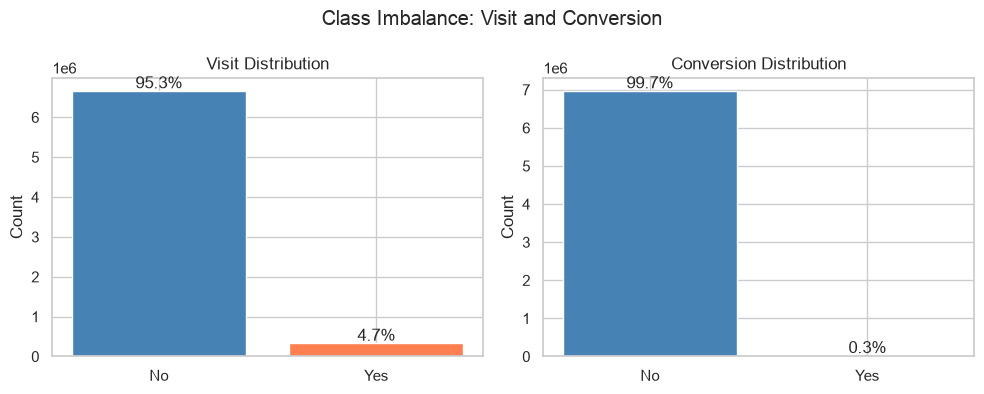

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, col in zip(axes, ["visit", "conversion"]):
    counts = df[col].value_counts().sort_index()
    ax.bar(["No", "Yes"], counts.values, color=["steelblue", "coral"])
    ax.set_title(f"{col.capitalize()} Distribution")
    ax.set_ylabel("Count")
    for i, v in enumerate(counts.values):
        ax.text(i, v + counts.max() * 0.01, f"{v/len(df):.1%}", ha="center")

plt.suptitle("Class Imbalance: Visit and Conversion")
plt.tight_layout()
plt.show()

**Dataset summary (Diemert et al., 2018):**

- 13.9M rows, 12 anonymized features: 4 continuous (f0, f2, f7, f10) and 8 categorical (up to 3,743 modalities for f8)
- Features were hashed to protect privacy while preserving predictive power
- Treatment ratio: 85% treated, 15% control (cost of holding back ads drives the imbalance)
- Visit rate: 4.7% | Conversion rate: 0.29%
- Null check confirms no missing values, which is expected as features were logged at treatment assignment time

## 4. Treatment Effect Analysis

In [8]:
print("Visit rate by treatment assignment:")
print(df.groupby("treatment")["visit"].mean().rename({0: "control", 1: "treated"}))

# Exclude treatment users who were targeted but never exposed (T=1, E=0)
# This compares exposed treatment users vs control users cleanly
df_exposed_vs_control = df[~((df["treatment"] == 1) & (df["exposure"] == 0))]

print("\nVisit rate: exposed treatment vs control (excluding T=1, E=0):")
print(df_exposed_vs_control.groupby("treatment")["visit"].mean().rename({0: "control", 1: "treatment (exposed only)"}))

Visit rate by treatment assignment:
treatment
control    0.038201
treated    0.048544
Name: visit, dtype: float64

Visit rate: exposed treatment vs control (excluding T=1, E=0):
treatment
control                     0.038201
treatment (exposed only)    0.414540
Name: visit, dtype: float64


In [9]:
ATE_treatment = df[df["treatment"] == 1]["visit"].mean() - df[df["treatment"] == 0]["visit"].mean()

rate_exposed = df_exposed_vs_control[df_exposed_vs_control["treatment"] == 1]["visit"].mean()
rate_control = df_exposed_vs_control[df_exposed_vs_control["treatment"] == 0]["visit"].mean()
ATE_exposure = rate_exposed - rate_control

print(f"ATE (by treatment assignment):       {ATE_treatment:.4f}")
print(f"ATE (exposed treatment vs control):  {ATE_exposure:.4f}")

ATE (by treatment assignment):       0.0103
ATE (exposed treatment vs control):  0.3763


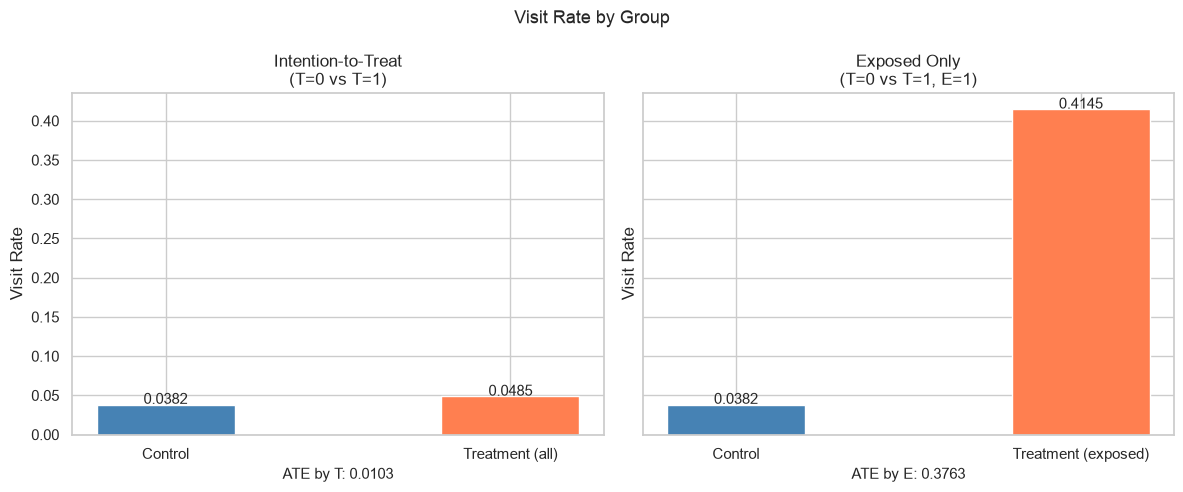

In [10]:
# intention-to-treat: T=0 vs T=1
group_t = df.groupby("treatment")["visit"].mean().reset_index()
group_t["group"] = group_t["treatment"].map({0: "Control", 1: "Treatment (all)"})

# exposed-only: T=0 vs (T=1, E=1)
df_exp = df[~((df["treatment"] == 1) & (df["exposure"] == 0))]
group_e = df_exp.groupby("treatment")["visit"].mean().reset_index()
group_e["group"] = group_e["treatment"].map({0: "Control", 1: "Treatment (exposed)"})

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, group, title, ate_label in zip(
    axes,
    [group_t, group_e],
    ["Intention-to-Treat\n(T=0 vs T=1)", "Exposed Only\n(T=0 vs T=1, E=1)"],
    ["ATE by T", "ATE by E"]
):
    bars = ax.bar(group["group"], group["visit"], color=["steelblue", "coral"], width=0.4)
    for bar, val in zip(bars, group["visit"]):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.001, f"{val:.4f}", ha="center", fontsize=11)
    ax.set_ylabel("Visit Rate")
    ax.set_title(title)
    rate_t = group[group["treatment"] == 1]["visit"].values[0]
    rate_c = group[group["treatment"] == 0]["visit"].values[0]
    ax.set_xlabel(f"{ate_label}: {rate_t - rate_c:.4f}", fontsize=11)

plt.suptitle("Visit Rate by Group", fontsize=13)
plt.tight_layout()
plt.savefig("../images/conversion_by_group.png", bbox_inches="tight")
plt.show()


Per Diemert et al. (2018) Eq. 5, uplift is formally defined using `T` (treatment assignment):

```
u(x) = E[Y | T=1, X=x] - E[Y | T=0, X=x]
```

The `exposure` column (`E`) captures whether the user actually saw an ad. The paper establishes T=0 implies E=0, and that the effect of T on outcomes is mediated through E.

- **ATE by T** (intention-to-treat): paper's formal definition, includes treatment users who were never actually exposed
- **ATE by E** (as-treated): stronger signal, restricted to users who genuinely saw an ad, but deviates from the paper's setup

## 5. Covariate Balance

Compare feature distributions between treatment and control groups. In a proper RCT, T ⊥ X holds so distributions should be nearly identical.

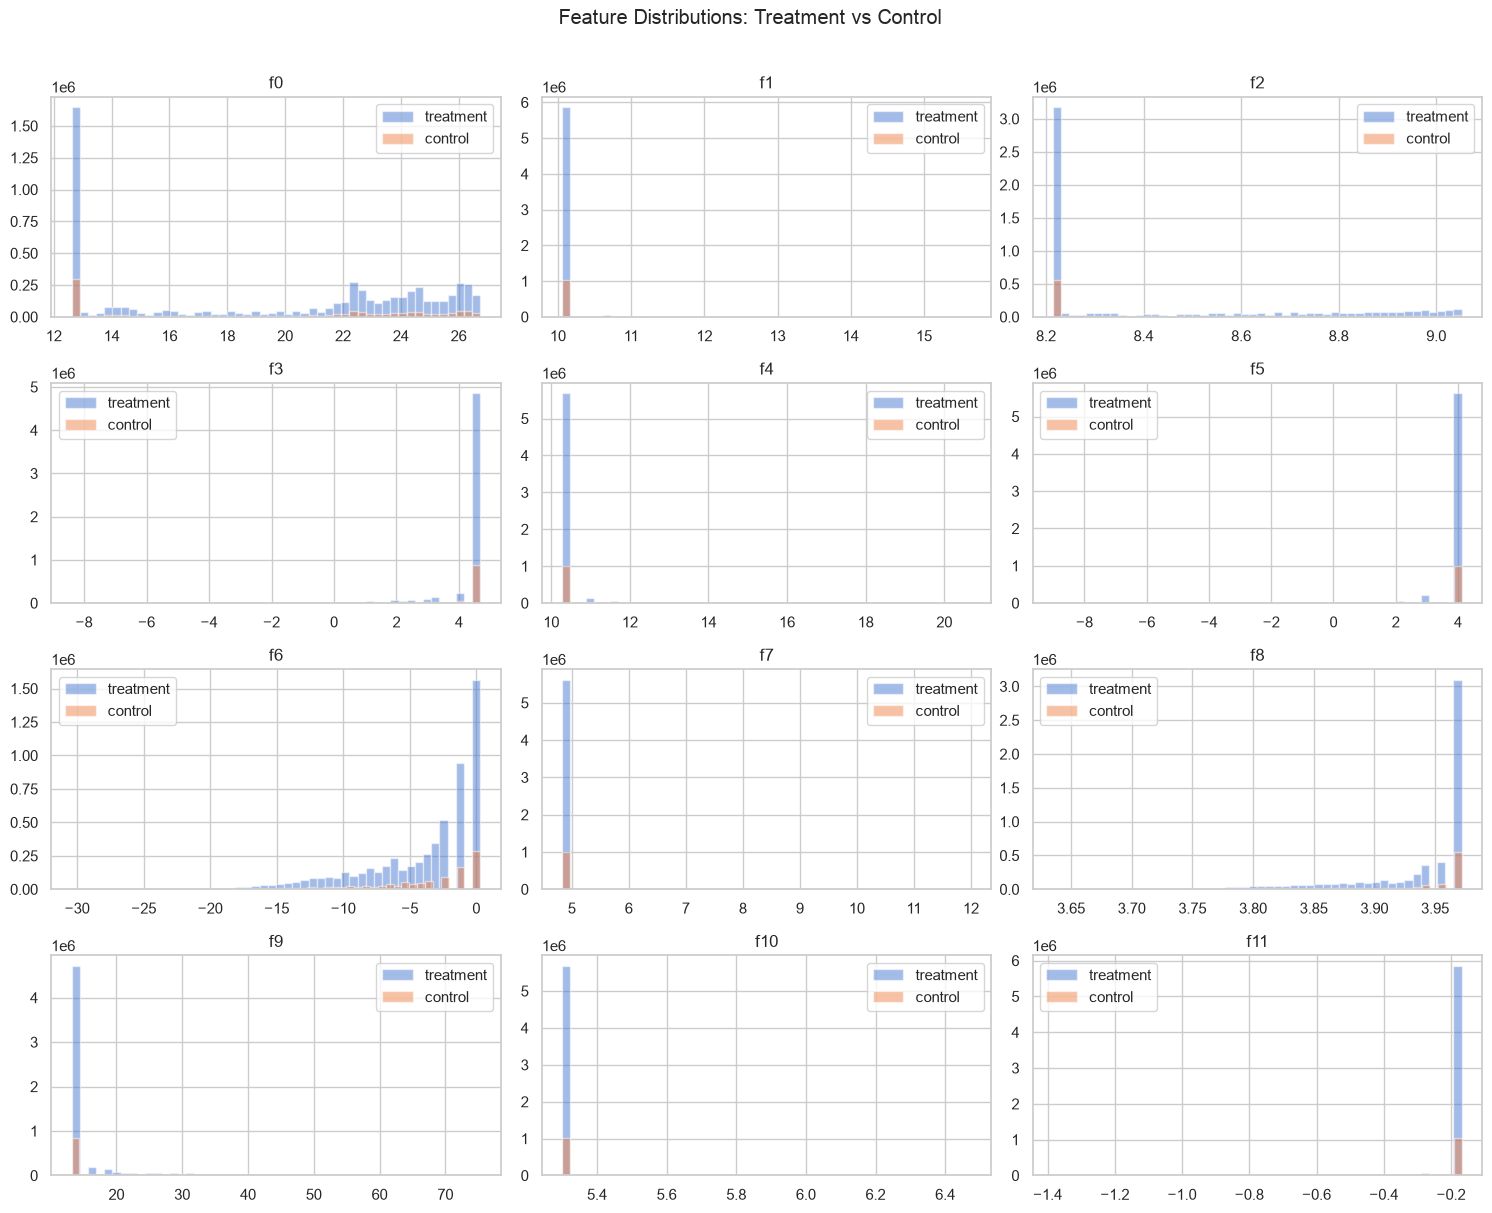

In [11]:
features = [f"f{i}" for i in range(12)]
fig, axes = plt.subplots(4, 3, figsize=(15, 12))
for i, feat in enumerate(features):
    ax = axes[i // 3, i % 3]
    df[df["treatment"] == 1][feat].hist(ax=ax, alpha=0.5, label="treatment", bins=50)
    df[df["treatment"] == 0][feat].hist(ax=ax, alpha=0.5, label="control", bins=50)
    ax.set_title(feat)
    ax.legend()
plt.suptitle("Feature Distributions: Treatment vs Control", y=1.01)
plt.tight_layout()
plt.savefig("../images/feature_distributions.png", bbox_inches="tight")
plt.show()

**Insight:** Treatment and control distributions overlap almost perfectly across all 12 features, confirming that `T ⊥ X` holds. 
The randomization was properly implemented and no confounding correction is needed.

**Note**: the y-axis shows raw counts. Since 85% of users are in treatment, the control bars (orange) always appear smaller. 
The shapes are what matter for balance, and the shapes align.

**Feature observations**:
- f0 is bimodal with two distinct clusters
- f3, f5, f6, f9 are heavily skewed with long tails
- f1, f4, f7, f10, f11 are highly concentrated, most mass in one bin

---

### Citation

```bibtex
@inproceedings{Diemert2018,
  author = {{Diemert Eustache, Betlei Artem} and Renaudin, Christophe and Massih-Reza, Amini},
  title={A Large Scale Benchmark for Uplift Modeling},
  publisher = {ACM},
  booktitle = {Proceedings of the AdKDD and TargetAd Workshop, KDD, London, United Kingdom, August, 20, 2018},
  year = {2018}
}
```